<div style="background-color:black; color:white; font-weight:bold; 
padding:10px; text-align:center; font-size:60px;">
🚀 TRAINING PROJECT
</div>

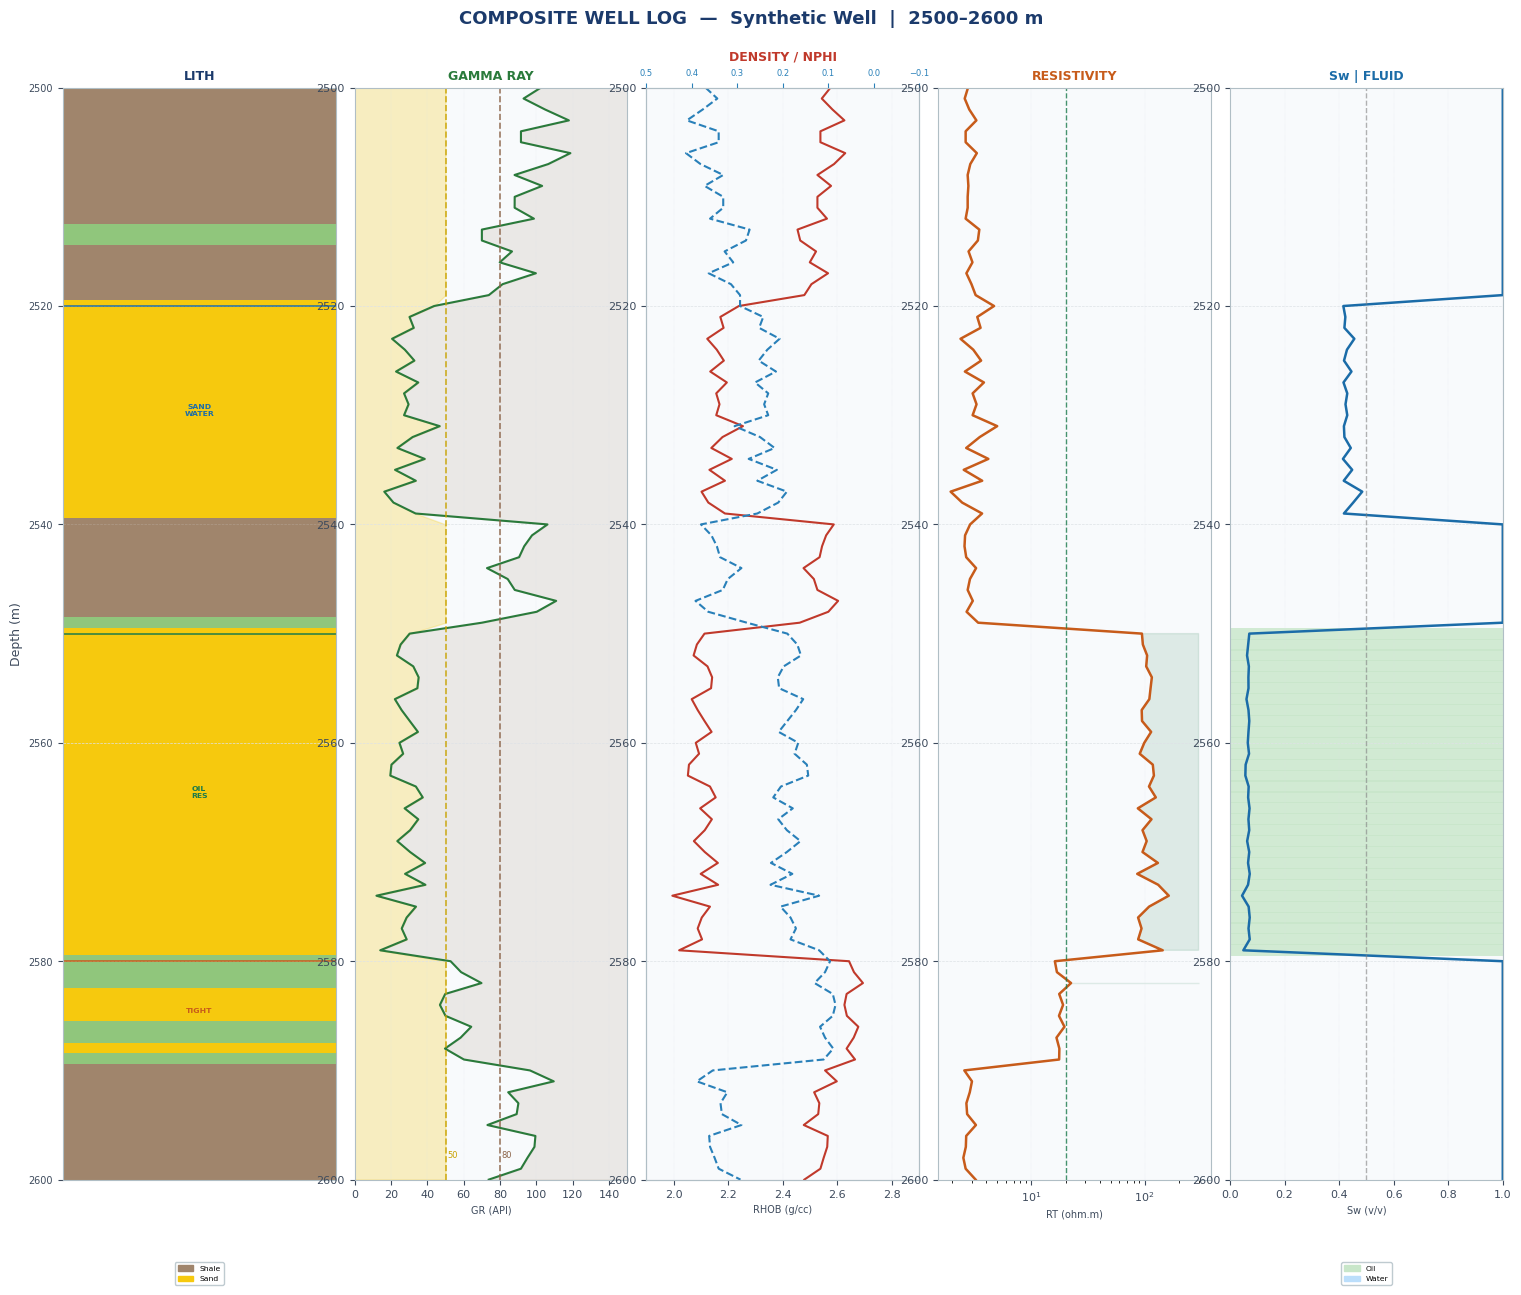

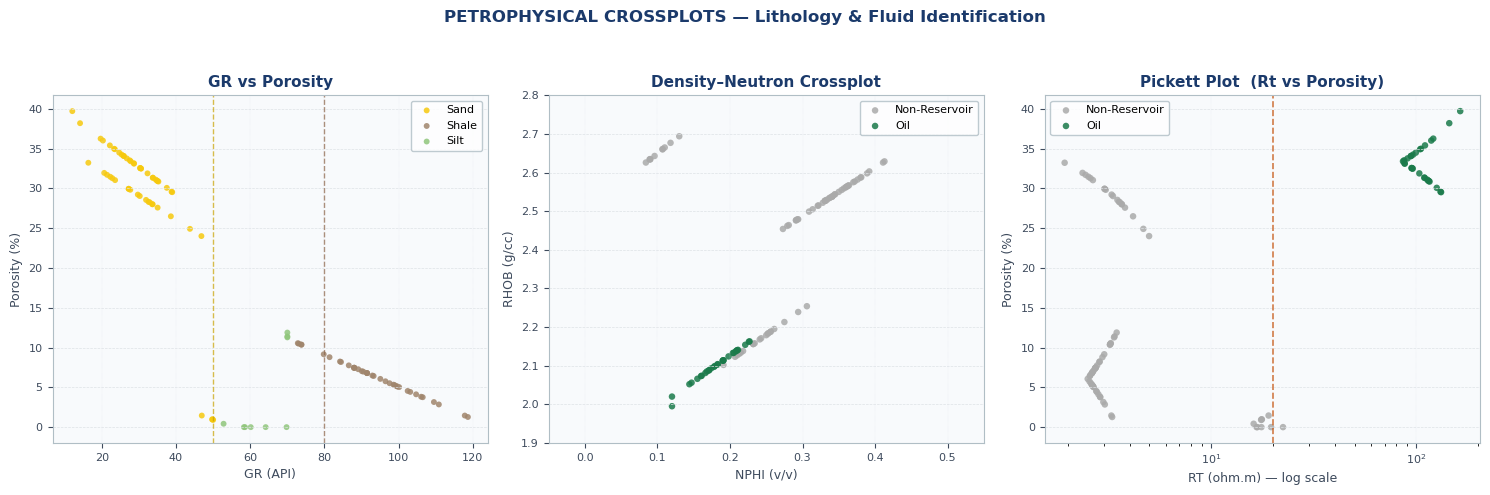

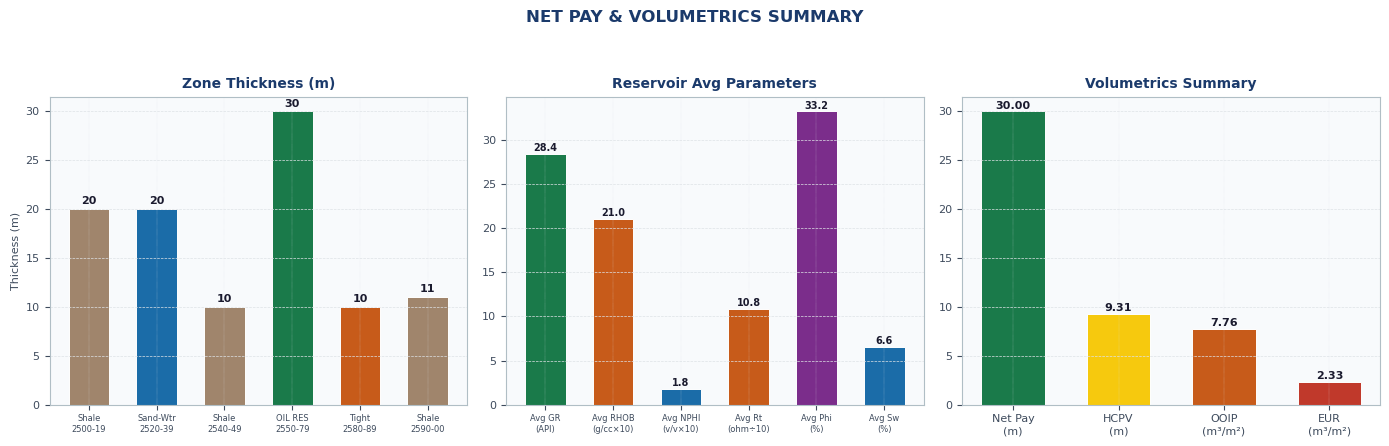

✅  well_log.png | crossplots.png | volumetrics.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════
# 1. توليد البيانات
# ══════════════════════════════════════
np.random.seed(42)
depth = np.arange(2500, 2601, 1)

def zone(d):
    if   2500 <= d <= 2519: return 'shale'
    elif 2520 <= d <= 2539: return 'sand_water'
    elif 2540 <= d <= 2549: return 'shale'
    elif 2550 <= d <= 2579: return 'sand_oil'
    elif 2580 <= d <= 2589: return 'tight'
    else:                   return 'shale'

zones = [zone(d) for d in depth]
GR, RHOB, NPHI, RT = [], [], [], []

for z in zones:
    ns = np.random.randn()
    if z == 'shale':
        GR.append(np.clip(95+15*ns, 70, 140))
        RHOB.append(np.clip(2.55+0.05*ns, 2.40, 2.70))
        NPHI.append(np.clip(0.35+0.04*ns, 0.25, 0.50))
        RT.append(np.clip(2.5+0.5*abs(ns), 1.0, 6.0))
    elif z == 'sand_water':
        GR.append(np.clip(32+8*ns, 15, 50))
        RHOB.append(np.clip(2.18+0.04*ns, 2.05, 2.30))
        NPHI.append(np.clip(0.25+0.03*ns, 0.18, 0.32))
        RT.append(np.clip(3.5+0.8*ns, 1.5, 6.0))
    elif z == 'sand_oil':
        GR.append(np.clip(28+7*ns, 12, 48))
        RHOB.append(np.clip(2.10+0.04*ns, 1.98, 2.22))
        NPHI.append(np.clip(0.18+0.03*ns, 0.12, 0.26))
        RT.append(np.clip(85+30*abs(ns), 30, 180))
    elif z == 'tight':
        GR.append(np.clip(55+10*ns, 40, 75))
        RHOB.append(np.clip(2.65+0.03*ns, 2.55, 2.75))
        NPHI.append(np.clip(0.10+0.02*ns, 0.06, 0.16))
        RT.append(np.clip(15+5*abs(ns), 8, 30))

df = pd.DataFrame({
    'Depth': depth,
    'GR':    np.round(GR, 2),
    'RHOB':  np.round(RHOB, 3),
    'NPHI':  np.round(NPHI, 3),
    'RT':    np.round(RT, 2),
    'Zone':  zones
})

df['Lithology'] = df['GR'].apply(lambda x: 'Shale' if x > 70 else ('Sand' if x < 50 else 'Silt'))
df['PHID'] = ((2.65 - df['RHOB']) / (2.65 - 1.00)).clip(0, 0.45)
df['Sw']   = np.sqrt((1.0 * 0.05) / (df['PHID']**2 * df['RT'])).clip(0, 1)
df['So']   = (1 - df['Sw']).clip(0, 1)
df['Fluid'] = 'Non-Reservoir'
df.loc[(df['GR']<50) & (df['PHID']>0.10) & (df['RT']>10) & (df['Sw']<0.5),  'Fluid'] = 'Oil'
df.loc[(df['GR']<50) & (df['PHID']>0.10) & (df['RT']>10) & (df['Sw']>=0.5), 'Fluid'] = 'Water'

# ══════════════════════════════════════
# 2. إعداد الستايل العام
# ══════════════════════════════════════
AX_BG    = '#F8FAFC'
GRID_C   = '#DEE2E6'
BORDER_C = '#B0BEC5'
TITLE_C  = '#1B3A6B'
TK_C     = '#3D4A5C'

def style_ax(ax):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors=TK_C, labelsize=8)
    for sp in ax.spines.values():
        sp.set_color(BORDER_C); sp.set_linewidth(0.8)
    ax.grid(True, axis='y', color=GRID_C, linewidth=0.5, linestyle='--')
    ax.grid(True, axis='x', color=GRID_C, linewidth=0.3, linestyle=':')

# ══════════════════════════════════════
# الرسم 1: Composite Well Log (5 Tracks)
# ══════════════════════════════════════
fig1 = plt.figure(figsize=(16, 13), facecolor='white')
gs   = GridSpec(1, 5, figure=fig1, wspace=0.07,
                left=0.07, right=0.97, top=0.91, bottom=0.07)

# Track 0 — Lithology
ax0 = fig1.add_subplot(gs[0])
for _, row in df.iterrows():
    c = '#A0856C' if row['Lithology']=='Shale' else ('#F6C90E' if row['Lithology']=='Sand' else '#90C67C')
    ax0.barh(row['Depth'], 1, height=1.1, color=c, left=0)
ax0.set_facecolor(AX_BG); ax0.set_ylim(2600, 2500); ax0.set_xlim(0, 1)
ax0.set_title('LITH', color=TITLE_C, fontsize=9, fontweight='bold')
ax0.set_xticks([])
ax0.set_ylabel('Depth (m)', color=TK_C, fontsize=9)
ax0.tick_params(colors=TK_C, labelsize=7)
for sp in ax0.spines.values(): sp.set_color(BORDER_C)
ax0.grid(True, axis='y', color=GRID_C, linewidth=0.5, linestyle='--')

zone_labels = [(2500,2519,'#A0856C','SHALE'), (2520,2539,'#1B6CA8','SAND\nWATER'),
               (2540,2549,'#A0856C','SHALE'), (2550,2579,'#1A7A4A','OIL\nRES'),
               (2580,2589,'#C75B1A','TIGHT'), (2590,2600,'#A0856C','SHALE')]
for yt, yb, col, lbl in zone_labels:
    ax0.axhline(yt, color=col, linewidth=1.2, alpha=0.9)
    ax0.text(0.5, (yt+yb)/2, lbl, color=col, fontsize=5.5,
             fontweight='bold', va='center', ha='center')

lp = [mpatches.Patch(color='#A0856C', label='Shale'),
      mpatches.Patch(color='#F6C90E', label='Sand')]
ax0.legend(handles=lp, loc='lower center', fontsize=5.5,
           facecolor='white', edgecolor=BORDER_C,
           bbox_to_anchor=(0.5, -0.1), ncol=1)

# Track 1 — Gamma Ray
ax1 = fig1.add_subplot(gs[1]); style_ax(ax1)
ax1.set_ylim(2600, 2500); ax1.set_xlim(0, 150)
ax1.set_title('GAMMA RAY', color='#2A7A3B', fontsize=9, fontweight='bold')
ax1.set_xlabel('GR (API)', color=TK_C, fontsize=7)
ax1.fill_betweenx(df['Depth'], df['GR'], 150, alpha=0.15, color='#A0856C')
ax1.fill_betweenx(df['Depth'], 0, df['GR'].where(df['GR']<50, 50), alpha=0.25, color='#F6C90E')
ax1.plot(df['GR'], df['Depth'], color='#2A7A3B', linewidth=1.5)
ax1.axvline(50, color='#C8A200', linewidth=1.2, linestyle='--', alpha=0.85)
ax1.axvline(80, color='#8B6347', linewidth=1.2, linestyle='--', alpha=0.85)
ax1.text(51, 2598, '50', color='#C8A200', fontsize=6)
ax1.text(81, 2598, '80', color='#8B6347', fontsize=6)

# Track 2 — Density / Neutron
ax2 = fig1.add_subplot(gs[2]); style_ax(ax2)
ax2.set_ylim(2600, 2500); ax2.set_xlim(1.9, 2.9)
ax2.set_title('DENSITY / NPHI', color='#C0392B', fontsize=9, fontweight='bold')
ax2.set_xlabel('RHOB (g/cc)', color=TK_C, fontsize=7)
ax2.plot(df['RHOB'], df['Depth'], color='#C0392B', linewidth=1.5, label='RHOB')
ax2t = ax2.twiny()
ax2t.set_xlim(0.5, -0.1)
ax2t.plot(df['NPHI'], df['Depth'], color='#2980B9', linewidth=1.5, linestyle='--', label='NPHI')
ax2t.tick_params(colors='#2980B9', labelsize=6)
for sp in ax2t.spines.values(): sp.set_color(BORDER_C)

# Track 3 — Resistivity
ax3 = fig1.add_subplot(gs[3]); style_ax(ax3)
ax3.set_ylim(2600, 2500); ax3.set_xscale('log')
ax3.set_title('RESISTIVITY', color='#C75B1A', fontsize=9, fontweight='bold')
ax3.set_xlabel('RT (ohm.m)', color=TK_C, fontsize=7)
ax3.semilogx(df['RT'], df['Depth'], color='#C75B1A', linewidth=1.8)
ax3.fill_betweenx(df['Depth'], df['RT'], 300, where=df['RT']>20, alpha=0.12, color='#1A7A4A')
ax3.axvline(20, color='#1A7A4A', linewidth=1, linestyle='--', alpha=0.8)

# Track 4 — Sw / Fluid
ax4 = fig1.add_subplot(gs[4]); style_ax(ax4)
ax4.set_ylim(2600, 2500); ax4.set_xlim(0, 1)
ax4.set_title('Sw | FLUID', color='#1B6CA8', fontsize=9, fontweight='bold')
ax4.set_xlabel('Sw (v/v)', color=TK_C, fontsize=7)
for _, row in df.iterrows():
    if row['Fluid'] == 'Oil':   ax4.barh(row['Depth'], 1, height=1.1, color='#C8E6C9', alpha=0.8)
    elif row['Fluid'] == 'Water': ax4.barh(row['Depth'], 1, height=1.1, color='#BBDEFB', alpha=0.7)
ax4.plot(df['Sw'], df['Depth'], color='#1B6CA8', linewidth=1.8)
ax4.axvline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.6)
lf = [mpatches.Patch(color='#C8E6C9', label='Oil'),
      mpatches.Patch(color='#BBDEFB', label='Water')]
ax4.legend(handles=lf, loc='lower center', fontsize=5.5,
           facecolor='white', edgecolor=BORDER_C,
           bbox_to_anchor=(0.5, -0.1), ncol=1)

fig1.suptitle('COMPOSITE WELL LOG  —  Synthetic Well  |  2500–2600 m',
              color=TITLE_C, fontsize=13, fontweight='bold', y=0.97)
plt.savefig('well_log.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ══════════════════════════════════════
# الرسم 2: Petrophysical Crossplots
# ══════════════════════════════════════
fig2, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
fluid_c = {'Oil':'#1A7A4A', 'Water':'#1B6CA8', 'Non-Reservoir':'#AAAAAA'}
lith_c  = {'Shale':'#A0856C', 'Sand':'#F6C90E', 'Silt':'#90C67C'}

for ax in axes: style_ax(ax)

# Plot 1 — GR vs Porosity
for lith, grp in df.groupby('Lithology'):
    axes[0].scatter(grp['GR'], grp['PHID']*100,
                    c=lith_c.get(lith,'grey'), s=18, alpha=0.85,
                    label=lith, edgecolors='none')
axes[0].set_xlabel('GR (API)', color=TK_C, fontsize=9)
axes[0].set_ylabel('Porosity (%)', color=TK_C, fontsize=9)
axes[0].set_title('GR vs Porosity', color=TITLE_C, fontsize=11, fontweight='bold')
axes[0].axvline(50, color='#C8A200', linewidth=1, linestyle='--', alpha=0.7)
axes[0].axvline(80, color='#8B6347', linewidth=1, linestyle='--', alpha=0.7)
axes[0].legend(facecolor='white', edgecolor=BORDER_C, fontsize=8)

# Plot 2 — Density-Neutron Crossplot
for fluid, grp in df.groupby('Fluid'):
    axes[1].scatter(grp['NPHI'], grp['RHOB'],
                    c=fluid_c.get(fluid,'grey'), s=22, alpha=0.85,
                    label=fluid, edgecolors='none')
axes[1].set_xlabel('NPHI (v/v)', color=TK_C, fontsize=9)
axes[1].set_ylabel('RHOB (g/cc)', color=TK_C, fontsize=9)
axes[1].set_xlim(-0.05, 0.55); axes[1].set_ylim(1.9, 2.8)
axes[1].set_title('Density–Neutron Crossplot', color=TITLE_C, fontsize=11, fontweight='bold')
axes[1].legend(facecolor='white', edgecolor=BORDER_C, fontsize=8)

# Plot 3 — Pickett Plot
for fluid, grp in df.groupby('Fluid'):
    axes[2].scatter(grp['RT'], grp['PHID']*100,
                    c=fluid_c.get(fluid,'grey'), s=22, alpha=0.85,
                    label=fluid, edgecolors='none')
axes[2].set_xscale('log')
axes[2].set_xlabel('RT (ohm.m) — log scale', color=TK_C, fontsize=9)
axes[2].set_ylabel('Porosity (%)', color=TK_C, fontsize=9)
axes[2].set_title('Pickett Plot  (Rt vs Porosity)', color=TITLE_C, fontsize=11, fontweight='bold')
axes[2].axvline(20, color='#C75B1A', linewidth=1.2, linestyle='--', alpha=0.8)
axes[2].legend(facecolor='white', edgecolor=BORDER_C, fontsize=8)

fig2.suptitle('PETROPHYSICAL CROSSPLOTS — Lithology & Fluid Identification',
              color=TITLE_C, fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('crossplots.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ══════════════════════════════════════
# الرسم 3: Volumetrics Summary
# ══════════════════════════════════════
oil_df   = df[df['Fluid'] == 'Oil']
avg_phi  = oil_df['PHID'].mean()
avg_sw   = oil_df['Sw'].mean()
avg_so   = oil_df['So'].mean()
avg_rt   = oil_df['RT'].mean()
net_pay  = len(oil_df)
HCPV     = net_pay * avg_phi * avg_so
OOIP     = HCPV / 1.20
EUR      = OOIP * 0.30

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4.5), facecolor='white')
for ax in axes3: style_ax(ax)

# Chart 1 — Zone Thickness
znames = ['Shale\n2500-19','Sand-Wtr\n2520-39','Shale\n2540-49',
          'OIL RES\n2550-79','Tight\n2580-89','Shale\n2590-00']
zthick = [20, 20, 10, 30, 10, 11]
zcols  = ['#A0856C','#1B6CA8','#A0856C','#1A7A4A','#C75B1A','#A0856C']
bars = axes3[0].bar(znames, zthick, color=zcols, edgecolor='white', linewidth=0.7, width=0.6)
axes3[0].set_title('Zone Thickness (m)', color=TITLE_C, fontweight='bold', fontsize=10)
axes3[0].set_ylabel('Thickness (m)', color=TK_C, fontsize=8)
for b, t in zip(bars, zthick):
    axes3[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, str(t),
                  ha='center', va='bottom', color='#1A1A2E', fontsize=8, fontweight='bold')
axes3[0].tick_params(axis='x', labelsize=6)

# Chart 2 — Reservoir Parameters
params = ['Avg GR\n(API)', 'Avg RHOB\n(g/cc×10)', 'Avg NPHI\n(v/v×10)',
          'Avg Rt\n(ohm÷10)', 'Avg Phi\n(%)', 'Avg Sw\n(%)']
vals   = [oil_df['GR'].mean(), oil_df['RHOB'].mean()*10, oil_df['NPHI'].mean()*10,
          avg_rt/10, avg_phi*100, avg_sw*100]
pcols  = ['#1A7A4A','#C75B1A','#1B6CA8','#C75B1A','#7B2D8B','#1B6CA8']
b2 = axes3[1].bar(params, vals, color=pcols, edgecolor='white', linewidth=0.7, width=0.6)
axes3[1].set_title('Reservoir Avg Parameters', color=TITLE_C, fontweight='bold', fontsize=10)
for b, v in zip(b2, vals):
    axes3[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f'{v:.1f}',
                  ha='center', va='bottom', color='#1A1A2E', fontsize=7, fontweight='bold')
axes3[1].tick_params(axis='x', labelsize=6)

# Chart 3 — Volumetrics
vlabels = ['Net Pay\n(m)', 'HCPV\n(m)', 'OOIP\n(m³/m²)', 'EUR\n(m³/m²)']
vvals   = [net_pay, HCPV, OOIP, EUR]
vcols   = ['#1A7A4A', '#F6C90E', '#C75B1A', '#C0392B']
b3 = axes3[2].bar(vlabels, vvals, color=vcols, edgecolor='white', linewidth=0.7, width=0.6)
axes3[2].set_title('Volumetrics Summary', color=TITLE_C, fontweight='bold', fontsize=10)
for b, v in zip(b3, vvals):
    axes3[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{v:.2f}',
                  ha='center', va='bottom', color='#1A1A2E', fontsize=8, fontweight='bold')
axes3[2].tick_params(axis='x', labelsize=8)

fig3.suptitle('NET PAY & VOLUMETRICS SUMMARY', color=TITLE_C, fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('volumetrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("✅  well_log.png | crossplots.png | volumetrics.png")

<div style="background-color:black; color:white; font-weight:bold;
padding:15px; text-align:center; font-size:60px; border-radius:8px;">
🚀 REAL PROJECT
</div>

In [ ]:
import lasio
import pandas as pd
import numpy as np

las = lasio.read('1056604800.las')

print("=== Well Info ===")
print(f"Well Name : {las.well.WELL.value}")
print(f"Field     : {las.well.FLD.value}")
print(f"Location  : {las.well.LOC.value}")

print("\n=== Available Curves ===")
for curve in las.curves:
    print(f"  {curve.mnemonic:12} | {curve.unit:10} | {curve.descr}")

=== Well Info ===
Well Name : A FISTFUL OF DOLLARS #1
Field     : WILDCAT
Location  : 632' FSL & 2020' FEL--

=== Available Curves ===
  DEPT         | FT         | Depth
  DCAL         | IN         | Litho Caliper
  DPOR         | PU         | Litho Density Porosity
  GR           | GAPI       | Gamma Ray
  NPOR         | PU         | Neutron Porosity
  PE           | BARN       | PE
  RHOC         | G/CC       | Litho Density Correction
  RILD         | OHM-M      | DIL Deep Resistivity
  RILM         | OHM-M      | DIL Medium Resistivity
  RLL3         | OHM-M      | DIL Shallow Resistivity
  SP           | MV         | DIL Spontaneous Potential
  MCAL         | IN         | Caliper from Microlog
  MI           | OHM-M      | Micro Inverse Resistivity
  MN           | OHM-M      | Micro Normal Resistivity


In [ ]:
import lasio
import pandas as pd
import numpy as np

las = lasio.read('1056604800.las')
df  = las.df().reset_index()
df.columns = df.columns.str.upper()
df  = df.replace(-999.25, np.nan)
df  = df.drop_duplicates('DEPT')
df  = df.sort_values('DEPT').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Depth: {df['DEPT'].min():.1f} – {df['DEPT'].max():.1f} ft")
print(f"Sample interval: {df['DEPT'].diff().median():.3f} ft")

print("\n=== Missing Values % ===")
key_curves = ['GR', 'DPOR', 'NPOR', 'RILD', 'DCAL', 'RHOC']
for col in key_curves:
    if col in df.columns:
        pct = df[col].isnull().sum() / len(df) * 100
        status = "✅ OK" if pct < 10 else ("⚠️ CHECK" if pct < 30 else "❌ BAD")
        print(f"  {col:8} : {pct:5.1f}%  {status}")

print("\n=== Log Range Check ===")
ranges = {
    'GR'  : (0,   200,  'GAPI'),
    'DPOR': (0,   45,   'PU'),
    'NPOR': (0,   45,   'PU'),
    'RILD': (0.1, 2000, 'OHM-M'),
    'DCAL': (4,   20,   'IN'),
}
for log, (vmin, vmax, unit) in ranges.items():
    if log in df.columns:
        lo = df[log].min()
        hi = df[log].max()
        ok = "✅" if lo >= vmin and hi <= vmax else "⚠️"
        print(f"  {ok} {log:6}: {lo:.2f} – {hi:.2f} {unit}")

print("\n=== Quick Stats ===")
print(df[key_curves].describe().round(2))

Rows: 9106
Depth: 3.5 – 4556.0 ft
Sample interval: 0.500 ft

=== Missing Values % ===
  GR       :   1.0%  ✅ OK
  DPOR     :  79.5%  ❌ BAD
  NPOR     :  79.7%  ❌ BAD
  RILD     :   0.9%  ✅ OK
  DCAL     :  79.5%  ❌ BAD
  RHOC     :  79.5%  ❌ BAD

=== Log Range Check ===
  ⚠️ GR    : 3.25 – 479.31 GAPI
  ⚠️ DPOR  : -243.68 – 31.26 PU
  ⚠️ NPOR  : 2.37 – 53.68 PU
  ⚠️ RILD  : 0.80 – 100000.00 OHM-M
  ⚠️ DCAL  : -6.24 – 8.38 IN

=== Quick Stats ===
            GR     DPOR     NPOR       RILD     DCAL     RHOC
count  9018.00  1867.00  1849.00    9027.00  1867.00  1867.00
mean     69.67     7.20    13.14    1827.31     7.76     0.06
std      34.38     8.80     6.64   13336.11     0.56     0.08
min       3.25  -243.68     2.37       0.80    -6.24    -2.26
25%      46.65     4.28     8.08       3.09     7.75     0.03
50%      66.34     6.73    12.17       5.48     7.81     0.05
75%      87.19     9.79    16.80      10.85     7.84     0.08
max     479.31    31.26    53.68  100000.00     8.38  

In [ ]:
depth_dpor_start = df.dropna(subset=['DPOR'])['DEPT'].min()
depth_dpor_end   = df.dropna(subset=['DPOR'])['DEPT'].max()

print(f"DPOR starts : {depth_dpor_start:.1f} ft")
print(f"DPOR ends   : {depth_dpor_end:.1f} ft")
print(f"Zone thick  : {depth_dpor_end - depth_dpor_start:.0f} ft")

zone = df[(df['DEPT'] >= depth_dpor_start)]
print(f"Rows in zone: {len(zone)}")

DPOR starts : 3600.0 ft
DPOR ends   : 4533.0 ft
Zone thick  : 933 ft
Rows in zone: 1913


In [ ]:
top = 3600.0
bot = 4533.0

df_zone = df[(df['DEPT'] >= top) & (df['DEPT'] <= bot)].copy()
df_zone = df_zone.reset_index(drop=True)

df_zone.loc[df_zone['GR']   > 200,  'GR']   = np.nan
df_zone.loc[df_zone['DPOR'] < 0,    'DPOR'] = np.nan
df_zone.loc[df_zone['NPOR'] < 0,    'NPOR'] = np.nan
df_zone.loc[df_zone['RILD'] > 2000, 'RILD'] = np.nan
df_zone.loc[df_zone['RILD'] < 0.1,  'RILD'] = np.nan

print(f"Working Zone  : {top} – {bot} ft")
print(f"Thickness     : {bot - top:.0f} ft")
print(f"Rows          : {len(df_zone)}")
print(f"\n=== Final QC ===")
for col in ['GR','DPOR','NPOR','RILD']:
    pct = df_zone[col].isnull().sum() / len(df_zone) * 100
    lo  = df_zone[col].min()
    hi  = df_zone[col].max()
    status = "✅" if pct < 10 else "⚠️"
    print(f"  {status} {col:6}: missing {pct:4.1f}%  |  {lo:.2f} – {hi:.2f}")

Working Zone  : 3600.0 – 4533.0 ft
Thickness     : 933 ft
Rows          : 1867

=== Final QC ===
  ✅ GR    : missing  4.4%  |  19.61 – 191.51
  ✅ DPOR  : missing  0.3%  |  0.01 – 31.26
  ✅ NPOR  : missing  1.0%  |  2.37 – 53.68
  ✅ RILD  : missing  0.0%  |  1.07 – 122.26


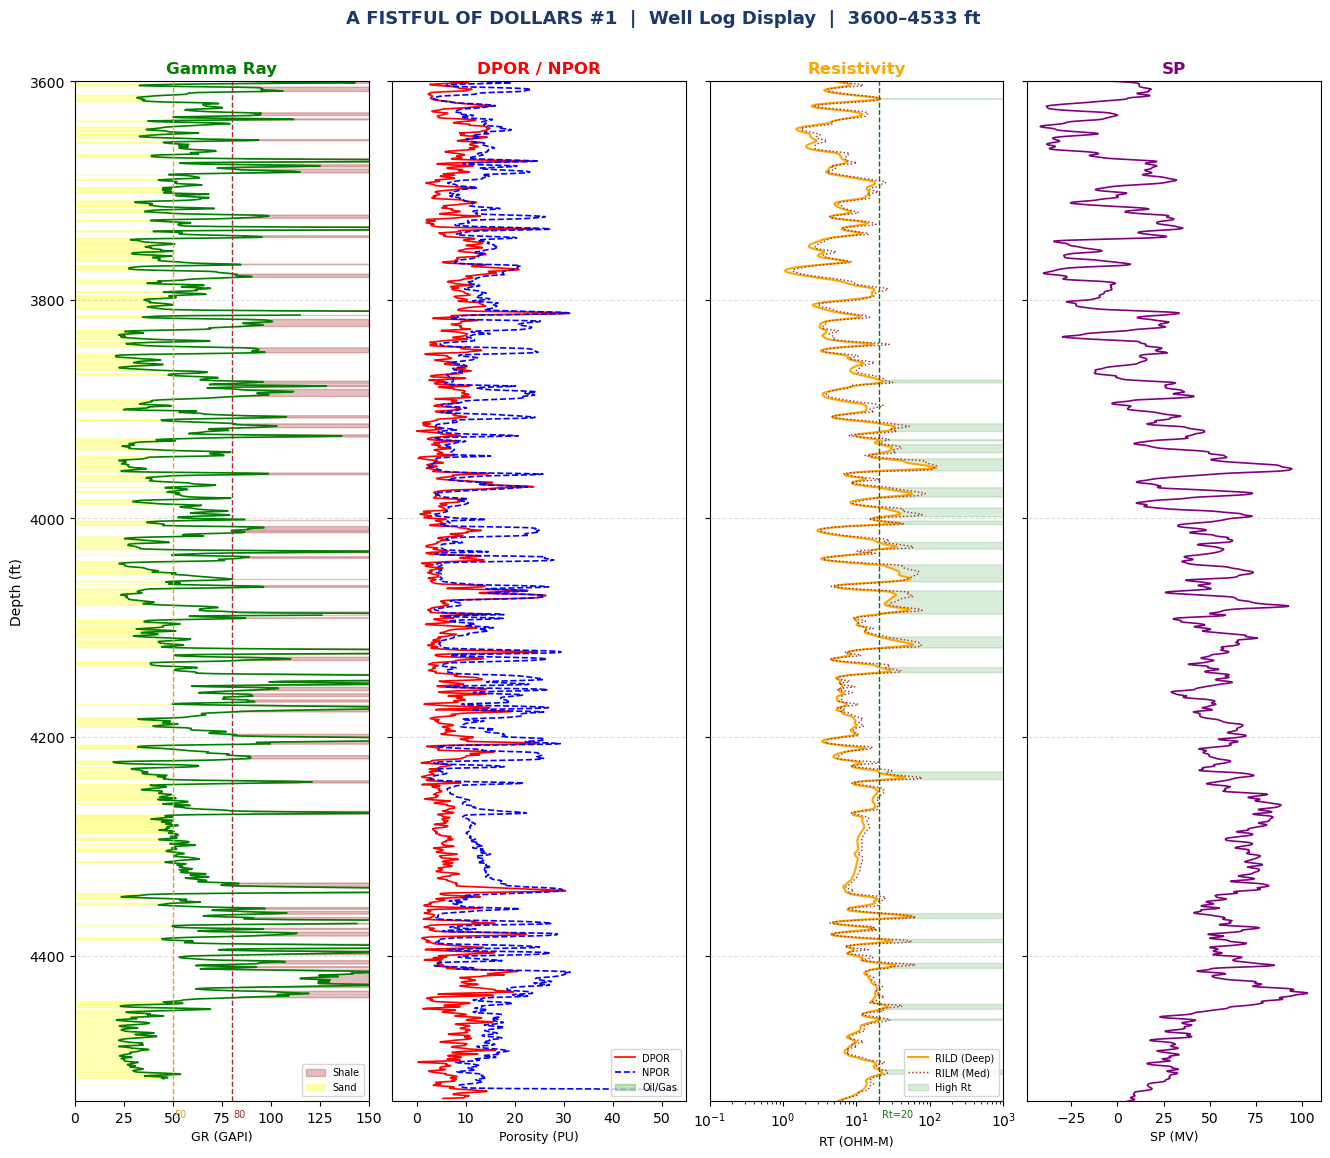

Saved: Well_Log_Display.png ✅


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 12))
fig.patch.set_facecolor('white')
gs  = GridSpec(1, 4, figure=fig, wspace=0.08,
               left=0.08, right=0.97, top=0.91, bottom=0.06)

depth = df_zone['DEPT']

# ── Track 1: GR ──
ax1 = fig.add_subplot(gs[0])
ax1.plot(df_zone['GR'], depth, color='green', linewidth=1.2)
ax1.fill_betweenx(depth, df_zone['GR'], 150,
                  where=df_zone['GR'] > 80,
                  alpha=0.3, color='brown', label='Shale')
ax1.fill_betweenx(depth, 0, df_zone['GR'],
                  where=df_zone['GR'] < 50,
                  alpha=0.3, color='yellow', label='Sand')
ax1.set_xlim(0, 150)
ax1.set_ylim(depth.max(), depth.min())
ax1.set_xlabel('GR (GAPI)', fontsize=9)
ax1.set_ylabel('Depth (ft)', fontsize=10)
ax1.set_title('Gamma Ray', fontweight='bold', color='green')
ax1.axvline(50, color='goldenrod', linewidth=1, linestyle='--')
ax1.axvline(80, color='brown',    linewidth=1, linestyle='--')
ax1.text(51, depth.max()+15, '50', fontsize=7, color='goldenrod')
ax1.text(81, depth.max()+15, '80', fontsize=7, color='brown')
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)
ax1.legend(fontsize=7, loc='lower right')

# ── Track 2: Porosity (DPOR + NPOR) ──
ax2 = fig.add_subplot(gs[1])
ax2.plot(df_zone['DPOR'], depth, color='red',  linewidth=1.2, label='DPOR')
ax2.plot(df_zone['NPOR'], depth, color='blue', linewidth=1.2, linestyle='--', label='NPOR')
# Crossover = Gas/Oil effect
ax2.fill_betweenx(depth, df_zone['DPOR'], df_zone['NPOR'],
                  where=df_zone['DPOR'] > df_zone['NPOR'],
                  alpha=0.25, color='green', label='Oil/Gas')
ax2.set_xlim(-5, 55)
ax2.set_ylim(depth.max(), depth.min())
ax2.set_xlabel('Porosity (PU)', fontsize=9)
ax2.set_title('DPOR / NPOR', fontweight='bold', color='red')
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)
ax2.legend(fontsize=7, loc='lower right')
ax2.set_yticklabels([])

# ── Track 3: Resistivity ──
ax3 = fig.add_subplot(gs[2])
ax3.semilogx(df_zone['RILD'], depth, color='orange', linewidth=1.5, label='RILD (Deep)')
if 'RILM' in df_zone.columns:
    ax3.semilogx(df_zone['RILM'], depth, color='brown',
                 linewidth=1, linestyle=':', label='RILM (Med)')
ax3.fill_betweenx(depth, df_zone['RILD'], 2000,
                  where=df_zone['RILD'] > 20,
                  alpha=0.15, color='green', label='High Rt')
ax3.set_xlim(0.1, 1000)
ax3.set_ylim(depth.max(), depth.min())
ax3.set_xlabel('RT (OHM-M)', fontsize=9)
ax3.set_title('Resistivity', fontweight='bold', color='orange')
ax3.axvline(20, color='green', linewidth=1, linestyle='--')
ax3.text(22, depth.max()+15, 'Rt=20', fontsize=7, color='green')
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)
ax3.legend(fontsize=7, loc='lower right')
ax3.set_yticklabels([])

# ── Track 4: SP (إن وجد) ──
ax4 = fig.add_subplot(gs[3])
if 'SP' in df_zone.columns:
    ax4.plot(df_zone['SP'], depth, color='purple', linewidth=1.2)
    ax4.set_xlabel('SP (MV)', fontsize=9)
    ax4.set_title('SP', fontweight='bold', color='purple')
else:
    ax4.plot(df_zone['RILD'] / df_zone['DPOR'].replace(0, np.nan),
             depth, color='gray', linewidth=1)
    ax4.set_xlabel('Rt/DPOR', fontsize=9)
    ax4.set_title('Rt / Porosity', fontweight='bold', color='gray')
ax4.set_ylim(depth.max(), depth.min())
ax4.grid(True, axis='y', linestyle='--', alpha=0.4)
ax4.set_yticklabels([])

# ── Title ──
fig.suptitle('A FISTFUL OF DOLLARS #1  |  Well Log Display  |  3600–4533 ft',
             fontsize=13, fontweight='bold', color='#1B3A6B', y=0.97)

plt.savefig('Well_Log_Display.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: Well_Log_Display.png ✅")

In [ ]:
GR_clean = df_zone['GR'].quantile(0.05)   
GR_shale = df_zone['GR'].quantile(0.95)   

print(f"GR_clean : {GR_clean:.1f} GAPI")
print(f"GR_shale : {GR_shale:.1f} GAPI")

df_zone['VSH'] = (df_zone['GR'] - GR_clean) / (GR_shale - GR_clean)
df_zone['VSH'] = df_zone['VSH'].clip(0, 1)

print(f"\nVSH range: {df_zone['VSH'].min():.2f} – {df_zone['VSH'].max():.2f}")
print(f"Avg VSH  : {df_zone['VSH'].mean():.2f}")

GR_clean : 26.6 GAPI
GR_shale : 118.9 GAPI

VSH range: 0.00 – 1.00
Avg VSH  : 0.36


In [ ]:
df_zone['PHID'] = df_zone['DPOR'] / 100     
df_zone['PHIN'] = df_zone['NPOR'] / 100

df_zone['PHIA'] = (df_zone['PHID'] + df_zone['PHIN']) / 2
df_zone['PHIA'] = df_zone['PHIA'].clip(0, 0.45)

print(f"PHID range: {df_zone['PHID'].min():.3f} – {df_zone['PHID'].max():.3f} v/v")
print(f"PHIN range: {df_zone['PHIN'].min():.3f} – {df_zone['PHIN'].max():.3f} v/v")
print(f"PHIA avg  : {df_zone['PHIA'].mean()*100:.1f}%")

PHID range: 0.000 – 0.313 v/v
PHIN range: 0.024 – 0.537 v/v
PHIA avg  : 10.3%


In [16]:
# ── Archie Parameters ──
a  = 1.0    # Tortuosity
m  = 2.0    # Cementation
n  = 2.0    # Saturation exponent
Rw = 0.05   # Formation water resistivity (ohm.m)

# ── معادلة Archie ──
df_zone['SW'] = ((a * Rw) / (df_zone['PHIA']**m * df_zone['RILD']))**(1/n)
df_zone['SW'] = df_zone['SW'].clip(0, 1)
df_zone['SO'] = 1 - df_zone['SW']

print(f"SW range: {df_zone['SW'].min():.2f} – {df_zone['SW'].max():.2f}")
print(f"Avg SW  : {df_zone['SW'].mean():.2f}")
print(f"Avg SO  : {df_zone['SO'].mean():.2f}")

SW range: 0.14 – 1.00
Avg SW  : 0.77
Avg SO  : 0.23


In [17]:
# ── Cutoffs ──
GR_cut  = 80      # GAPI
VSH_cut = 0.40
PHI_cut = 0.05    # v/v  (5%)
SW_cut  = 0.60
RT_cut  = 10      # ohm.m

# ── Flag Reservoir ──
df_zone['RESERVOIR'] = (
    (df_zone['GR']   < GR_cut)  &
    (df_zone['VSH']  < VSH_cut) &
    (df_zone['PHIA'] > PHI_cut) &
    (df_zone['SW']   < SW_cut)  &
    (df_zone['RILD'] > RT_cut)
).astype(int)

# ── حساب Net Pay ──
sample   = 0.5    # ft (sample interval)
net_pay  = df_zone['RESERVOIR'].sum() * sample
gross    = len(df_zone) * sample
NTG      = net_pay / gross

print(f"\n=== Net Pay Results ===")
print(f"Gross interval : {gross:.0f} ft")
print(f"Net Pay        : {net_pay:.1f} ft")
print(f"Net-to-Gross   : {NTG*100:.1f}%")

# ── Reservoir Stats ──
res = df_zone[df_zone['RESERVOIR'] == 1]
print(f"\n=== Reservoir Zone Stats ===")
print(f"Avg GR   : {res['GR'].mean():.1f} GAPI")
print(f"Avg PHIA : {res['PHIA'].mean()*100:.1f}%")
print(f"Avg SW   : {res['SW'].mean()*100:.1f}%")
print(f"Avg RILD : {res['RILD'].mean():.1f} ohm.m")


=== Net Pay Results ===
Gross interval : 934 ft
Net Pay        : 71.0 ft
Net-to-Gross   : 7.6%

=== Reservoir Zone Stats ===
Avg GR   : 39.3 GAPI
Avg PHIA : 13.0%
Avg SW   : 45.2%
Avg RILD : 18.7 ohm.m


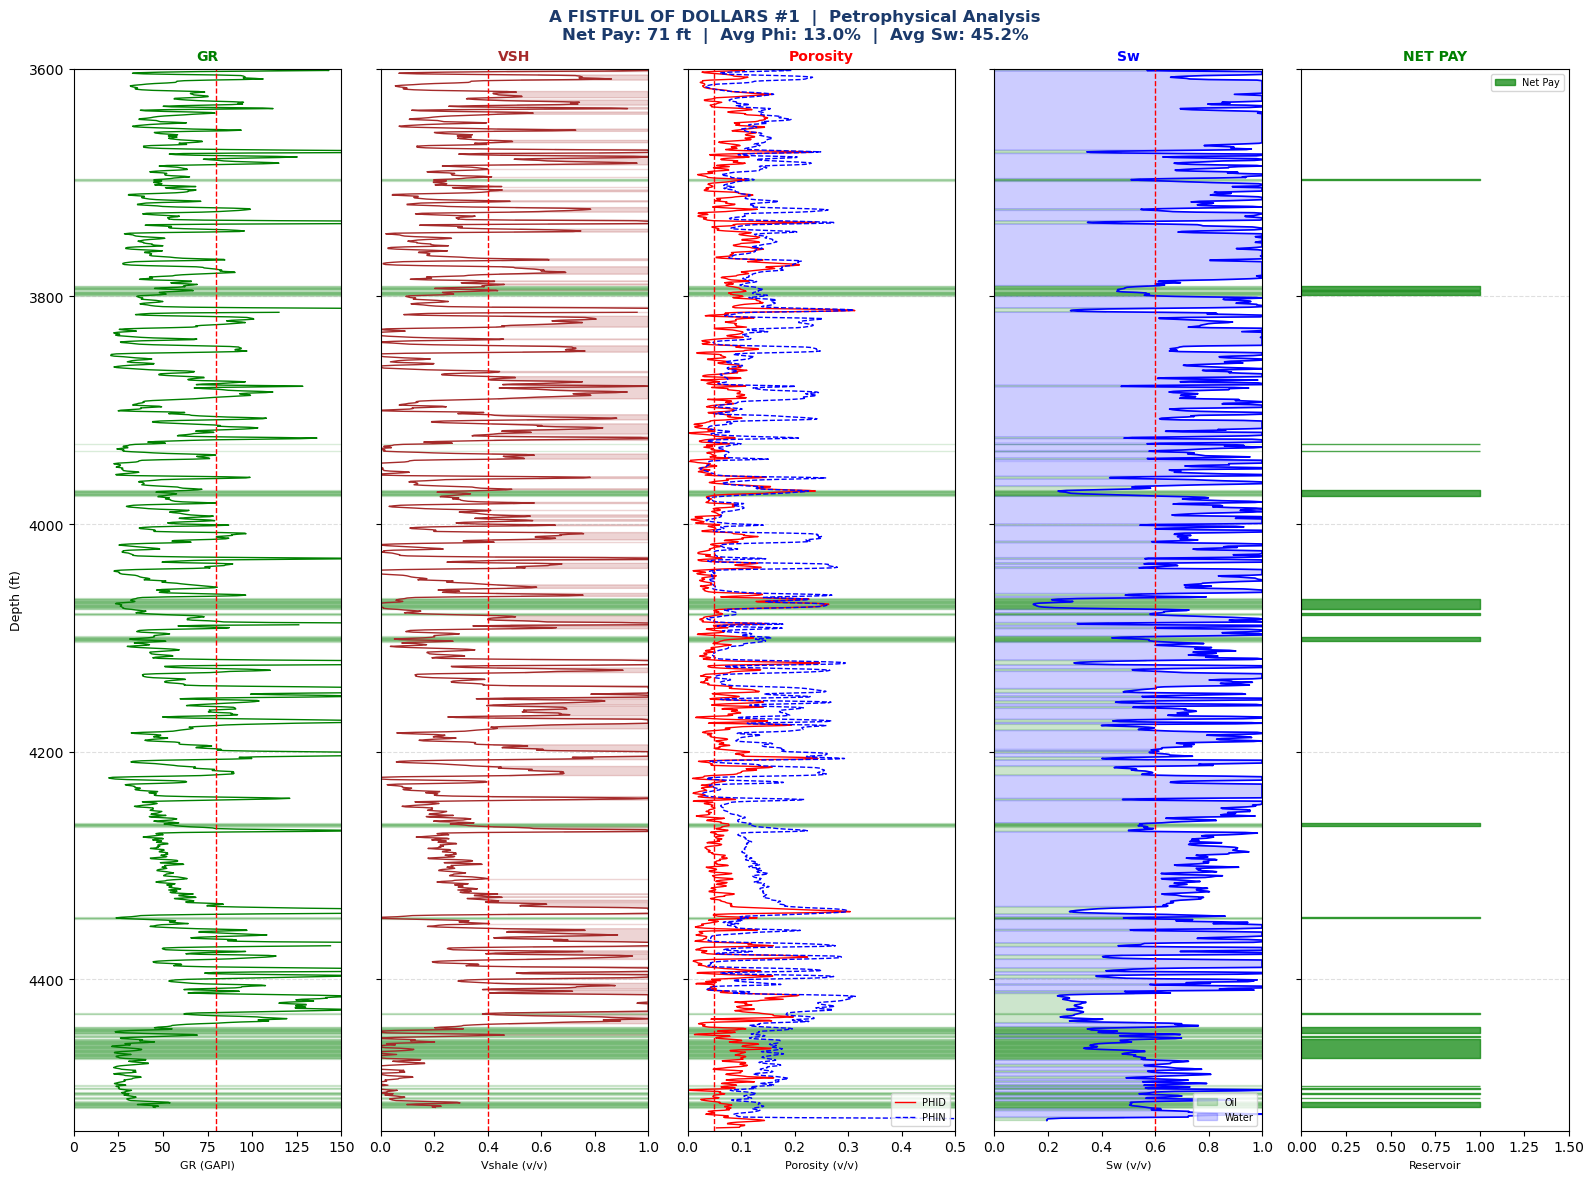

Saved ✅


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 12), sharey=True)
fig.patch.set_facecolor('white')
depth = df_zone['DEPT']

def shade_reservoir(ax):
    for _, row in df_zone[df_zone['RESERVOIR']==1].iterrows():
        ax.axhspan(row['DEPT']-0.25, row['DEPT']+0.25,
                   alpha=0.15, color='green')

# Track 1: GR
ax = axes[0]
ax.plot(df_zone['GR'], depth, color='green', linewidth=1)
ax.set_xlim(0, 150)
ax.set_ylim(depth.max(), depth.min())
ax.set_xlabel('GR (GAPI)', fontsize=8)
ax.set_title('GR', fontweight='bold', color='green', fontsize=10)
ax.axvline(GR_cut, color='red', linewidth=1, linestyle='--')
ax.set_ylabel('Depth (ft)', fontsize=9)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
shade_reservoir(ax)

# Track 2: VSH
ax = axes[1]
ax.plot(df_zone['VSH'], depth, color='brown', linewidth=1)
ax.fill_betweenx(depth, df_zone['VSH'], 1,
                 where=df_zone['VSH'] > VSH_cut,
                 alpha=0.2, color='brown')
ax.set_xlim(0, 1)
ax.set_ylim(depth.max(), depth.min())
ax.set_xlabel('Vshale (v/v)', fontsize=8)
ax.set_title('VSH', fontweight='bold', color='brown', fontsize=10)
ax.axvline(VSH_cut, color='red', linewidth=1, linestyle='--')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
shade_reservoir(ax)

# Track 3: Porosity
ax = axes[2]
ax.plot(df_zone['PHID'], depth, color='red',  linewidth=1, label='PHID')
ax.plot(df_zone['PHIN'], depth, color='blue', linewidth=1, linestyle='--', label='PHIN')
ax.set_xlim(0, 0.5)
ax.set_ylim(depth.max(), depth.min())
ax.set_xlabel('Porosity (v/v)', fontsize=8)
ax.set_title('Porosity', fontweight='bold', color='red', fontsize=10)
ax.axvline(PHI_cut, color='red', linewidth=1, linestyle='--')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
shade_reservoir(ax)

# Track 4: SW
ax = axes[3]
ax.plot(df_zone['SW'], depth, color='blue', linewidth=1.2)
ax.fill_betweenx(depth, 0, df_zone['SW'],
                 where=df_zone['SW'] < SW_cut,
                 alpha=0.2, color='green', label='Oil')
ax.fill_betweenx(depth, 0, df_zone['SW'],
                 where=df_zone['SW'] >= SW_cut,
                 alpha=0.2, color='blue', label='Water')
ax.set_xlim(0, 1)
ax.set_ylim(depth.max(), depth.min())
ax.set_xlabel('Sw (v/v)', fontsize=8)
ax.set_title('Sw', fontweight='bold', color='blue', fontsize=10)
ax.axvline(SW_cut, color='red', linewidth=1, linestyle='--')
ax.legend(fontsize=7, loc='lower right')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
shade_reservoir(ax)

# Track 5: Reservoir Flag
ax = axes[4]
ax.fill_betweenx(depth, 0, df_zone['RESERVOIR'],
                 where=df_zone['RESERVOIR']==1,
                 color='green', alpha=0.7, label='Net Pay')
ax.set_xlim(0, 1.5)
ax.set_ylim(depth.max(), depth.min())
ax.set_xlabel('Reservoir', fontsize=8)
ax.set_title('NET PAY', fontweight='bold', color='green', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# ── Title ──
fig.suptitle(
    f'A FISTFUL OF DOLLARS #1  |  Petrophysical Analysis\n'
    f'Net Pay: {net_pay:.0f} ft  |  Avg Phi: {res["PHIA"].mean()*100:.1f}%'
    f'  |  Avg Sw: {res["SW"].mean()*100:.1f}%',
    fontsize=12, fontweight='bold', color='#1B3A6B', y=0.98)

plt.tight_layout()
plt.savefig('Petrophysical_Analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved ✅")

In [19]:
# شوف توزيع الـ Sw
print(df_zone['SW'].describe().round(3))
print(f"\nSw < 0.4  : {(df_zone['SW'] < 0.4).sum()} rows")
print(f"Sw < 0.5  : {(df_zone['SW'] < 0.5).sum()} rows")
print(f"Sw < 0.6  : {(df_zone['SW'] < 0.6).sum()} rows")

count    1848.000
mean        0.772
std         0.212
min         0.145
25%         0.627
50%         0.795
75%         1.000
max         1.000
Name: SW, dtype: float64

Sw < 0.4  : 122 rows
Sw < 0.5  : 210 rows
Sw < 0.6  : 404 rows


In [20]:
# ── حساب OOIP و EUR ──
res = df_zone[df_zone['RESERVOIR'] == 1]

avg_phi = res['PHIA'].mean()
avg_sw  = res['SW'].mean()
avg_so  = 1 - avg_sw
net_pay_m = 71 * 0.3048    # تحويل ft → m

Bo = 1.20   # Formation Volume Factor
RF = 0.30   # Recovery Factor 30%

HCPV = net_pay_m * avg_phi * avg_so
OOIP = HCPV / Bo
EUR  = OOIP * RF

print("=" * 40)
print(f"Net Pay        : {net_pay_m:.1f} m  ({71} ft)")
print(f"Avg Porosity   : {avg_phi*100:.1f}%")
print(f"Avg Sw         : {avg_sw*100:.1f}%")
print(f"Avg So         : {avg_so*100:.1f}%")
print("=" * 40)
print(f"HCPV           : {HCPV:.3f} m3/m2")
print(f"OOIP           : {OOIP:.3f} m3/m2")
print(f"EUR            : {EUR:.3f} m3/m2")
print("=" * 40)

Net Pay        : 21.6 m  (71 ft)
Avg Porosity   : 13.0%
Avg Sw         : 45.2%
Avg So         : 54.8%
HCPV           : 1.540 m3/m2
OOIP           : 1.283 m3/m2
EUR            : 0.385 m3/m2


In [ ]:


clean_water = df_zone[
    (df_zone['GR']   < 40) &
    (df_zone['RILD'] < 5)  &
    (df_zone['PHIA'] > 0.05)
].copy()

print(f"Clean water zone rows: {len(clean_water)}")

if len(clean_water) > 5:
    Rw_calc = (clean_water['PHIA']**2 * clean_water['RILD'] / 1.0)
    Rw_est  = Rw_calc.median()
    print(f"Estimated Rw = {Rw_est:.4f} ohm.m")
else:
    print("مفيش water zone واضحة — هنجرب قيم Rw مختلفة")

print("\n=== Effect of Rw on Avg Sw ===")
for rw in [0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]:
    sw_test = ((1.0 * rw) / (df_zone['PHIA']**2 * df_zone['RILD']))**0.5
    sw_test = sw_test.clip(0, 1)
    avg     = sw_test.mean()
    oil_rows= (sw_test < 0.6).sum()
    print(f"  Rw={rw:.2f}  →  Avg Sw={avg*100:.1f}%  |  Sw<0.6: {oil_rows} rows")

Clean water zone rows: 60
Estimated Rw = 0.0467 ohm.m

=== Effect of Rw on Avg Sw ===
  Rw=0.01  →  Avg Sw=37.3%  |  Sw<0.6: 1732 rows
  Rw=0.02  →  Avg Sw=52.4%  |  Sw<0.6: 1259 rows
  Rw=0.05  →  Avg Sw=77.2%  |  Sw<0.6: 404 rows
  Rw=0.08  →  Avg Sw=87.6%  |  Sw<0.6: 178 rows
  Rw=0.10  →  Avg Sw=91.3%  |  Sw<0.6: 137 rows
  Rw=0.15  →  Avg Sw=95.4%  |  Sw<0.6: 95 rows
  Rw=0.20  →  Avg Sw=96.9%  |  Sw<0.6: 57 rows


In [22]:
# ════════════════════════════════════
# VOLUMETRIC ANALYSIS
# ════════════════════════════════════

res = df_zone[df_zone['RESERVOIR'] == 1]

# ── Parameters ──
avg_phi    = res['PHIA'].mean()
avg_sw     = res['SW'].mean()
avg_so     = 1 - avg_sw
net_pay_ft = df_zone['RESERVOIR'].sum() * 0.5
net_pay_m  = net_pay_ft * 0.3048
gross_m    = len(df_zone) * 0.5 * 0.3048
NTG        = net_pay_m / gross_m

# ── Volumetrics ──
Bo = 1.20
RF = 0.30

HCPV = net_pay_m * avg_phi * avg_so
OOIP = HCPV / Bo
EUR  = OOIP * RF

# ── Zones تفصيلية ──
print("=" * 50)
print("   VOLUMETRIC ANALYSIS — A FISTFUL OF DOLLARS #1")
print("=" * 50)
print(f"\n── Input Parameters ──")
print(f"  Gross Interval : {gross_m:.1f} m  ({gross_m/0.3048:.0f} ft)")
print(f"  Net Pay        : {net_pay_m:.1f} m  ({net_pay_ft:.0f} ft)")
print(f"  Net-to-Gross   : {NTG*100:.1f}%")
print(f"  Avg Porosity   : {avg_phi*100:.1f}%")
print(f"  Avg Sw         : {avg_sw*100:.1f}%")
print(f"  Avg So         : {avg_so*100:.1f}%")
print(f"  Bo             : {Bo} rm3/sm3")
print(f"  Recovery Factor: {RF*100:.0f}%")

print(f"\n── Volumetrics (per m2 drainage area) ──")
print(f"  HCPV : {HCPV:.3f} m3/m2")
print(f"  OOIP : {OOIP:.3f} m3/m2")
print(f"  EUR  : {EUR:.3f} m3/m2")

print(f"\n── Reservoir Classification ──")
if avg_phi >= 0.20:
    phi_class = "Excellent"
elif avg_phi >= 0.15:
    phi_class = "Good"
elif avg_phi >= 0.10:
    phi_class = "Fair"
else:
    phi_class = "Poor"

if avg_sw <= 0.40:
    sw_class = "Oil — High Confidence"
elif avg_sw <= 0.60:
    sw_class = "Oil — Moderate Confidence"
else:
    sw_class = "Uncertain — Needs Review"

print(f"  Porosity Class : {phi_class} ({avg_phi*100:.1f}%)")
print(f"  Fluid Type     : {sw_class}")
print(f"  NTG Class      : {'Good' if NTG > 0.3 else 'Low'} ({NTG*100:.1f}%)")
print("=" * 50)

   VOLUMETRIC ANALYSIS — A FISTFUL OF DOLLARS #1

── Input Parameters ──
  Gross Interval : 284.5 m  (934 ft)
  Net Pay        : 21.6 m  (71 ft)
  Net-to-Gross   : 7.6%
  Avg Porosity   : 13.0%
  Avg Sw         : 45.2%
  Avg So         : 54.8%
  Bo             : 1.2 rm3/sm3
  Recovery Factor: 30%

── Volumetrics (per m2 drainage area) ──
  HCPV : 1.540 m3/m2
  OOIP : 1.283 m3/m2
  EUR  : 0.385 m3/m2

── Reservoir Classification ──
  Porosity Class : Fair (13.0%)
  Fluid Type     : Oil — Moderate Confidence
  NTG Class      : Low (7.6%)


In [ ]:
Rw = 0.0467

df_zone['SW'] = ((1.0 * Rw) / (df_zone['PHIA']**2 * df_zone['RILD']))**0.5
df_zone['SW'] = df_zone['SW'].clip(0, 1)
df_zone['SO'] = 1 - df_zone['SW']

df_zone['RESERVOIR'] = (
    (df_zone['GR']   < 80)   &
    (df_zone['VSH']  < 0.40) &
    (df_zone['PHIA'] > 0.05) &
    (df_zone['SW']   < 0.60) &
    (df_zone['RILD'] > 10)
).astype(int)

res        = df_zone[df_zone['RESERVOIR'] == 1]
net_pay_ft = df_zone['RESERVOIR'].sum() * 0.5
net_pay_m  = net_pay_ft * 0.3048
avg_phi    = res['PHIA'].mean()
avg_sw     = res['SW'].mean()
avg_so     = 1 - avg_sw

print(f"Net Pay  : {net_pay_ft:.0f} ft  ({net_pay_m:.1f} m)")
print(f"Avg Phi  : {avg_phi*100:.1f}%")
print(f"Avg Sw   : {avg_sw*100:.1f}%")
print(f"Avg So   : {avg_so*100:.1f}%")

# ── Volumetrics ──
Bo   = 1.20
RF   = 0.30
HCPV = net_pay_m * avg_phi * avg_so
OOIP = HCPV / Bo
EUR  = OOIP * RF

print(f"\nHCPV : {HCPV:.3f} m3/m2")
print(f"OOIP : {OOIP:.3f} m3/m2")
print(f"EUR  : {EUR:.3f} m3/m2")

Net Pay  : 76 ft  (23.2 m)
Avg Phi  : 12.6%
Avg Sw   : 44.7%
Avg So   : 55.3%

HCPV : 1.620 m3/m2
OOIP : 1.350 m3/m2
EUR  : 0.405 m3/m2
